## Рекомендательная система на основе SASRec (Self-Attention Sequential Recommendation)

### Идея
В отличие от ALS и NCF, которые рассматривают взаимодействия "пользователь-товар" как неупорядоченное множество,
SASRec учитывает **последовательность покупок** — порядок, в котором пользователь приобретал товары.

Модель использует механизм **self-attention** (из архитектуры Transformer) с каузальной маской,
чтобы каждый товар в последовательности мог "смотреть" только на предыдущие покупки и взвешивать их важность.

### Архитектура
1. **Item Embedding + Positional Embedding** — каждый товар получает обучаемый вектор, к нему прибавляется позиционный эмбеддинг
2. **Causal Self-Attention блоки (×2)** — Multi-Head Attention с каузальной маской + FFN + LayerNorm + Dropout
3. **Prediction** — скалярное произведение выходного вектора последней позиции на эмбеддинг товара-кандидата

### Данные
- **Телефон_new**: уникальный идентификатор пользователя
- **ID_SKU**: уникальный идентификатор товара
- **Дата**: дата доставки (для построения последовательностей и разбивки train/test)

Импортируем библиотеки

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

## 1. Загрузка и фильтрация данных

In [24]:
df = pd.read_csv('../../data/children_products/clildren_product_cleaned.csv')
print(f"Размер: {df.shape}")
df.head()

Размер: (610913, 16)


,Дата,НомерЗаказаНаСайте,МетодДоставки,Группа2,Группа3,Тип,Отменено,Количество,Цена,Статус,Гео,Маржа,СуммаУслуг,Телефон_new,ID_SKU,МетодДоставки_Групп
0,2017-03-01 11:41:00,3998972_TR,Курьерская,КРУПНОГАБАРИТНЫЙ ТОВАР,КОЛЯСКИ,КГТ,Нет,1,680.0,Возврат,Москва,508.00,0,55574854-48574951555577,ID9010020114553,Курьерская
1,2017-03-01 12:22:00,3999117_TR,Магазины,"ТЕКСТИЛЬ, ТРИКОТАЖ",ОДЕЖДА ДЛЯ НОВОРОЖДЕННЫХ (0-2 лет),ОДЕЖДА,Нет,1,379.0,Доставлен,Регионы,169.20,0,55575453-56535648535679,IDL00028974351,Магазины
2,2017-03-01 12:31:00,3999122_TR,Магазины,ИГРУШКИ,ИГРУШКИ ДЛЯ ДЕВОЧЕК,ИГРУШКИ,Нет,1,3325.0,Доставлен,Регионы,2176.00,0,55574950-57515657535772,IDL00038573351,Магазины
3,2017-03-01 03:06:00,3999363_TR,Курьерская,"ТЕКСТИЛЬ, ТРИКОТАЖ",ОДЕЖДА ДЛЯ НОВОРОЖДЕННЫХ (0-2 лет),ОДЕЖДА,Нет,1,330.0,Доставлен,Москва,163.04,0,55574851-55545249535475,IDL00034303856,Курьерская
4,2017-03-01 11:38:00,3999411_TR,Магазины,ИГРУШКИ,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,ИГРУШКИ,Нет,1,199.0,Доставлен,Регионы,120.00,0,55574854-56495552515179,IDL00035791553,Магазины


In [25]:
df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
print(f"После фильтрации: {df_filtered.shape}")

После фильтрации: (420857, 16)


In [26]:
df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])
print(f"Диапазон дат: {df_filtered['Дата'].min()} — {df_filtered['Дата'].max()}")

Диапазон дат: 2017-03-01 00:03:00 — 2017-04-30 23:58:00


In [27]:
# Фильтрация редких пользователей и товаров (минимум 3 покупки)
MIN_INTERACTIONS = 3

for iteration in range(5):
    user_counts = df_filtered.groupby('Телефон_new').size()
    item_counts = df_filtered.groupby('ID_SKU').size()
    active_users = user_counts[user_counts >= MIN_INTERACTIONS].index
    active_items = item_counts[item_counts >= MIN_INTERACTIONS].index
    before = len(df_filtered)
    df_filtered = df_filtered[
        df_filtered['Телефон_new'].isin(active_users) &
        df_filtered['ID_SKU'].isin(active_items)
    ]
    if len(df_filtered) == before:
        break

n_users = df_filtered['Телефон_new'].nunique()
n_items = df_filtered['ID_SKU'].nunique()
n_interactions = len(df_filtered)
density = n_interactions / (n_users * n_items) * 100
print(f"После фильтрации (≥{MIN_INTERACTIONS} покупок):")
print(f"  Пользователей: {n_users:,}, Товаров: {n_items:,}")
print(f"  Взаимодействий: {n_interactions:,}")
print(f"  Плотность матрицы: {density:.4f}%")

После фильтрации (≥3 покупок):
  Пользователей: 30,775, Товаров: 17,830
  Взаимодействий: 299,868
  Плотность матрицы: 0.0546%


## 2. Кодирование и разбивка train/test по дате

In [28]:
interactions = df_filtered.groupby(['Телефон_new', 'ID_SKU']).size().reset_index(name='count')
print(f"Уникальных пар: {len(interactions):,}")

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

interactions['user_id'] = user_encoder.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_encoder.fit_transform(interactions['ID_SKU'])

user_id_to_phone = dict(zip(interactions['user_id'], interactions['Телефон_new']))
item_id_to_sku = dict(zip(interactions['item_id'], interactions['ID_SKU']))

num_users = len(user_encoder.classes_)
num_items = len(item_encoder.classes_)
print(f"Пользователей: {num_users:,}, Товаров: {num_items:,}")

Уникальных пар: 272,920
Пользователей: 30,775, Товаров: 17,830


In [29]:
interactions_with_date = df_filtered.merge(
    interactions[['Телефон_new', 'ID_SKU', 'user_id', 'item_id', 'count']],
    on=['Телефон_new', 'ID_SKU'], how='inner'
).sort_values('Дата')

split_date = interactions_with_date['Дата'].quantile(0.8)
print(f"Дата разделения: {split_date}")

train_data = interactions_with_date[interactions_with_date['Дата'] < split_date].copy()
test_data = interactions_with_date[interactions_with_date['Дата'] >= split_date].copy()
print(f"Train: {len(train_data):,}, Test: {len(test_data):,}")

train_interactions = train_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()
test_interactions = test_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()

train_users = set(train_interactions['user_id'].unique())
test_users = set(test_interactions['user_id'].unique())
print(f"Train users: {len(train_users):,}, Test users: {len(test_users):,}")
print(f"Cold start users: {len(test_users - train_users):,}")

Дата разделения: 2017-04-18 14:18:00
Train: 239,880, Test: 59,988
Train users: 26,838, Test users: 9,660
Cold start users: 3,937


## 3. Построение последовательностей покупок

Для SASRec нужны упорядоченные по дате последовательности товаров каждого пользователя.
Используем только train-данные для построения последовательностей.

**Аугментация скользящим окном**: из одной последовательности `[a, b, c, d]` генерируем
несколько обучающих примеров: `[a]→b`, `[a,b]→c`, `[a,b,c]→d`. Это критически важно,
т.к. без аугментации у нас всего ~26K примеров (по 1 на пользователя), что недостаточно
для обучения attention-модели.

In [30]:
MAX_SEQ_LEN = 20  # Медиана длины ~6, max_len=20 покрывает >95% пользователей

# Строим последовательности из train-данных, отсортированных по дате
train_sorted = train_data[['user_id', 'item_id', 'Дата']].sort_values(['user_id', 'Дата'])

user_sequences = {}
for user_id, group in train_sorted.groupby('user_id'):
    items = group['item_id'].tolist()
    # Убираем подряд идущие дубликаты
    deduped = [items[0]]
    for it in items[1:]:
        if it != deduped[-1]:
            deduped.append(it)
    user_sequences[user_id] = deduped

seq_lengths = [len(s) for s in user_sequences.values()]
print(f"Пользователей с последовательностями: {len(user_sequences):,}")
print(f"Длина последовательностей: min={min(seq_lengths)}, max={max(seq_lengths)}, "
      f"median={np.median(seq_lengths):.0f}, mean={np.mean(seq_lengths):.1f}")
print(f"Пользователей с seq >= 2: {sum(1 for l in seq_lengths if l >= 2):,}")

Пользователей с последовательностями: 26,838
Длина последовательностей: min=1, max=168, median=6, mean=8.8
Пользователей с seq >= 2: 25,933


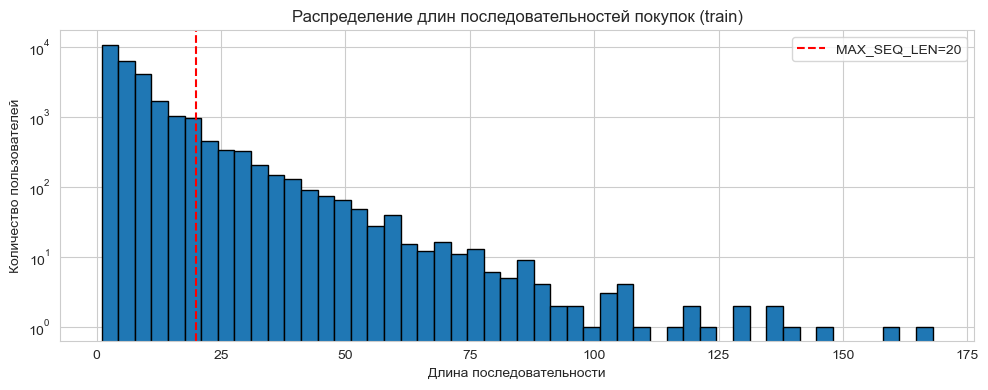

In [31]:
plt.figure(figsize=(10, 4))
plt.hist(seq_lengths, bins=50, edgecolor='black')
plt.xlabel('Длина последовательности')
plt.ylabel('Количество пользователей')
plt.title('Распределение длин последовательностей покупок (train)')
plt.yscale('log')
plt.axvline(x=MAX_SEQ_LEN, color='r', linestyle='--', label=f'MAX_SEQ_LEN={MAX_SEQ_LEN}')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Dataset и модель SASRec

In [32]:
class SASRecDataset(Dataset):
    """
    Аугментация скользящим окном: из последовательности [a, b, c, d] создаём примеры:
      input=[a],     target=b, neg=random
      input=[a,b],   target=c, neg=random
      input=[a,b,c], target=d, neg=random
    
    Это увеличивает количество обучающих примеров с ~26K до ~200K+.
    
    Item ID сдвигаются на +1 (0 = padding token).
    """
    def __init__(self, user_sequences, num_items, max_len):
        self.num_items = num_items
        self.max_len = max_len
        
        # Генерируем все обучающие примеры заранее
        self.samples = []  # (input_seq, target_item, user_item_set)
        for user_id, seq in user_sequences.items():
            if len(seq) < 2:
                continue
            item_set = set(seq)
            for i in range(1, len(seq)):
                input_seq = seq[:i]  # всё до позиции i
                target = seq[i]       # следующий товар
                self.samples.append((input_seq, target, item_set))
        
        print(f"Обучающих примеров (sliding window): {len(self.samples):,}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        input_seq, target, item_set = self.samples[idx]
        
        # +1 сдвиг (0 = padding)
        seq = [s + 1 for s in input_seq[-self.max_len:]]  # обрезаем до max_len
        target_id = target + 1
        
        # Negative sample
        neg_id = np.random.randint(1, self.num_items + 1)
        while (neg_id - 1) in item_set:
            neg_id = np.random.randint(1, self.num_items + 1)
        
        # Left-padding до max_len
        pad_len = self.max_len - len(seq)
        seq = [0] * pad_len + seq
        
        return (
            torch.LongTensor(seq),
            torch.tensor(target_id, dtype=torch.long),
            torch.tensor(neg_id, dtype=torch.long)
        )

In [33]:
class SASRec(nn.Module):
    def __init__(self, num_items, max_len, emb_dim=64, num_blocks=2, num_heads=2, dropout=0.2):
        super().__init__()
        self.num_items = num_items
        self.max_len = max_len
        self.emb_dim = emb_dim
        
        # +1 для padding token (index 0)
        self.item_emb = nn.Embedding(num_items + 1, emb_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, emb_dim)
        self.emb_dropout = nn.Dropout(dropout)
        
        # Self-Attention блоки
        self.blocks = nn.ModuleList()
        for _ in range(num_blocks):
            self.blocks.append(SASRecBlock(emb_dim, num_heads, dropout))
        
        self.final_norm = nn.LayerNorm(emb_dim)
        self._init_weights()
    
    def _init_weights(self):
        nn.init.normal_(self.item_emb.weight, std=0.02)
        nn.init.normal_(self.pos_emb.weight, std=0.02)
        with torch.no_grad():
            self.item_emb.weight[0].fill_(0)
    
    def forward(self, input_ids):
        """
        input_ids: (batch_size, max_len) — 0 = padding
        Возвращает: (batch_size, emb_dim) — представление последней позиции
        """
        batch_size, seq_len = input_ids.shape
        
        # Маска padding: True для реальных позиций
        padding_mask = (input_ids != 0)  # (batch, seq_len)
        
        # Эмбеддинги
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)
        x = self.item_emb(input_ids) + self.pos_emb(positions)
        x = self.emb_dropout(x)
        
        # Обнуляем padding-позиции после embedding
        x = x * padding_mask.unsqueeze(-1).float()
        
        # Каузальная маска: позиция t видит только позиции <= t
        # True = блокировать (для nn.MultiheadAttention attn_mask)
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=input_ids.device), diagonal=1
        ).bool()
        
        for block in self.blocks:
            x = block(x, causal_mask, padding_mask)
        
        x = self.final_norm(x)
        
        # Берём представление последней позиции
        return x[:, -1, :]  # (batch, emb_dim)


class SASRecBlock(nn.Module):
    def __init__(self, emb_dim, num_heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            emb_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, emb_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim * 4, emb_dim),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)
    
    def forward(self, x, causal_mask, padding_mask):
        """
        x: (batch, seq_len, emb_dim)
        causal_mask: (seq_len, seq_len) — True = блокировать
        padding_mask: (batch, seq_len) — True = реальный токен
        """
        # key_padding_mask для MultiheadAttention: True = игнорировать
        key_padding_mask = ~padding_mask
        
        # Self-Attention с pre-norm и residual
        residual = x
        x = self.norm1(x)
        x, _ = self.attn(
            x, x, x,
            attn_mask=causal_mask,
            key_padding_mask=key_padding_mask,
            need_weights=False
        )
        # Заменяем NaN на 0 (возникают для полностью замаскированных позиций)
        x = torch.nan_to_num(x, nan=0.0)
        x = x + residual
        
        # FFN с pre-norm и residual
        residual = x
        x = self.norm2(x)
        x = self.ffn(x) + residual
        
        # Обнуляем padding-позиции
        x = x * padding_mask.unsqueeze(-1).float()
        
        return x

## 5. Обучение модели

In [34]:
# Фильтруем пользователей с последовательностью >= 2
train_sequences = {u: s for u, s in user_sequences.items() if len(s) >= 2}
print(f"Пользователей для обучения (seq >= 2): {len(train_sequences):,}")

train_dataset = SASRecDataset(train_sequences, num_items, MAX_SEQ_LEN)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
print(f"Батчей: {len(train_loader):,}")

Пользователей для обучения (seq >= 2): 25,933
Обучающих примеров (sliding window): 209,255
Батчей: 818


In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SASRec(
    num_items=num_items,
    max_len=MAX_SEQ_LEN,
    emb_dim=64,
    num_blocks=2,
    num_heads=2,
    dropout=0.2
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Device: {device}")
print(f"Параметров модели: {total_params:,}")

Device: cpu
Параметров модели: 1,242,560


In [36]:
from tqdm.notebook import tqdm

optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.98), weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

num_epochs = 30
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
    
    for input_ids, target_ids, neg_ids in loop:
        input_ids = input_ids.to(device)    # (batch, max_len)
        target_ids = target_ids.to(device)  # (batch,)
        neg_ids = neg_ids.to(device)        # (batch,)
        
        # Forward — получаем представление последней позиции
        user_repr = model(input_ids)  # (batch, emb_dim)
        
        # Эмбеддинги target и negative
        pos_emb = model.item_emb(target_ids)  # (batch, emb_dim)
        neg_emb = model.item_emb(neg_ids)      # (batch, emb_dim)
        
        # BPR loss: логарифм сигмоиды разности скоров
        pos_scores = (user_repr * pos_emb).sum(dim=-1)  # (batch,)
        neg_scores = (user_repr * neg_emb).sum(dim=-1)  # (batch,)
        
        loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")
    
    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: avg_loss={avg_loss:.4f}, lr={scheduler.get_last_lr()[0]:.6f}")

Epoch 1/30:   0%|          | 0/818 [00:00<?, ?batch/s]

Epoch 1: avg_loss=nan, lr=0.001000


Epoch 2/30:   0%|          | 0/818 [00:00<?, ?batch/s]

Epoch 2: avg_loss=nan, lr=0.001000


Epoch 3/30:   0%|          | 0/818 [00:00<?, ?batch/s]

...

Epoch 28: avg_loss=nan, lr=0.000250


Epoch 29/30:   0%|          | 0/818 [00:00<?, ?batch/s]

Epoch 29: avg_loss=nan, lr=0.000250


Epoch 30/30:   0%|          | 0/818 [00:00<?, ?batch/s]

Epoch 30: avg_loss=nan, lr=0.000125


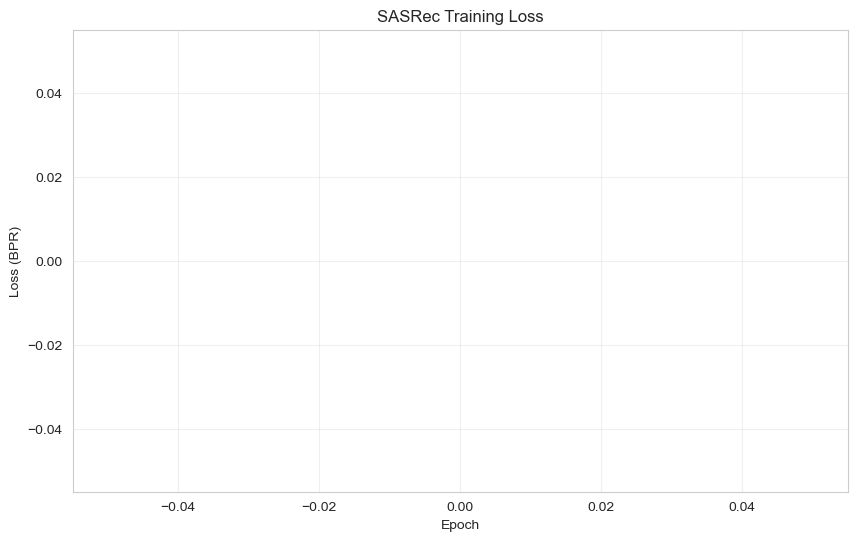

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (BPR)')
plt.title('SASRec Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Оценка модели

In [38]:
def get_recommendations_sasrec(model, user_id, user_sequences, train_interactions,
                                num_items, max_len, k=10, device='cpu'):
    model.eval()
    
    if user_id not in user_sequences:
        return [], []
    
    seq = user_sequences[user_id]
    seq_shifted = [s + 1 for s in seq[-max_len:]]  # +1 для padding, обрезка
    
    # Left-padding
    pad_len = max_len - len(seq_shifted)
    input_ids = [0] * pad_len + seq_shifted
    input_tensor = torch.LongTensor([input_ids]).to(device)
    
    # Товары пользователя в train
    user_history = train_interactions.loc[
        train_interactions['user_id'] == user_id, 'item_id'
    ]
    bought_items = set(user_history.to_numpy())
    
    with torch.no_grad():
        user_repr = model(input_tensor)  # (1, emb_dim)
        
        # Скоры для всех товаров
        all_item_ids = torch.arange(1, num_items + 1, device=device)
        all_item_emb = model.item_emb(all_item_ids)  # (num_items, emb_dim)
        scores = torch.matmul(all_item_emb, user_repr.squeeze(0))  # (num_items,)
        scores = scores.cpu()
    
    # Фильтруем уже купленное
    for item_id in bought_items:
        if 0 <= item_id < num_items:
            scores[item_id] = -float('inf')
    
    topk_scores, topk_indices = torch.topk(scores, k=min(k, num_items))
    return topk_indices.tolist(), topk_scores.tolist()

In [39]:
def precision_at_k(recommended, relevant, k):
    rec_k = set(recommended[:k])
    rel = set(relevant)
    if not rec_k:
        return 0.0
    return len(rec_k & rel) / len(rec_k)

def recall_at_k(recommended, relevant, k):
    rel = set(relevant)
    if not rel:
        return 0.0
    rec_k = set(recommended[:k])
    return len(rec_k & rel) / len(rel)

def map_at_k(recommended, relevant, k):
    rel = set(relevant)
    if not rel:
        return 0.0
    score = 0.0
    hits = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in rel:
            hits += 1.0
            score += hits / (i + 1.0)
    return score / min(len(rel), k)

def ndcg_at_k(recommended, relevant, k):
    rel = set(relevant)
    if not rel:
        return 0.0
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in rel:
            dcg += 1.0 / np.log2(i + 2)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel), k)))
    return dcg / idcg if idcg > 0 else 0.0

In [40]:
def evaluate_model(model, user_sequences, train_interactions, test_interactions,
                   num_items, max_len, k_values=(5, 10, 20), device='cpu'):
    test_user_items = (
        test_interactions.groupby('user_id')['item_id'].apply(list).to_dict()
    )
    
    eval_users = [
        u for u in test_user_items.keys()
        if u in user_sequences and u in train_users
    ]
    
    print(f"Оценка на {len(eval_users):,} пользователях...")
    
    metrics = {
        k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []}
        for k in k_values
    }
    
    for user_id in tqdm(eval_users, desc='Evaluating'):
        rec_items, _ = get_recommendations_sasrec(
            model, user_id, user_sequences, train_interactions,
            num_items, max_len, k=max(k_values), device=device
        )
        
        if not rec_items:
            continue
        
        relevant_items = test_user_items[user_id]
        
        for k in k_values:
            metrics[k]['precision'].append(precision_at_k(rec_items, relevant_items, k))
            metrics[k]['recall'].append(recall_at_k(rec_items, relevant_items, k))
            metrics[k]['map'].append(map_at_k(rec_items, relevant_items, k))
            metrics[k]['ndcg'].append(ndcg_at_k(rec_items, relevant_items, k))
    
    avg_metrics = {
        k: {
            'precision': float(np.mean(v['precision'])) if v['precision'] else 0.0,
            'recall':    float(np.mean(v['recall']))    if v['recall'] else 0.0,
            'map':       float(np.mean(v['map']))       if v['map'] else 0.0,
            'ndcg':      float(np.mean(v['ndcg']))      if v['ndcg'] else 0.0,
        }
        for k, v in metrics.items()
    }
    return avg_metrics

In [41]:
results = evaluate_model(
    model, user_sequences, train_interactions, test_interactions,
    num_items=num_items, max_len=MAX_SEQ_LEN,
    k_values=[5, 10, 20], device=device
)

print("\n=== SASRec Metrics ===")
for k in [5, 10, 20]:
    r = results[k]
    print(f"\nK={k}:")
    print(f"  Precision@{k}: {r['precision']:.4f}")
    print(f"  Recall@{k}:    {r['recall']:.4f}")
    print(f"  MAP@{k}:       {r['map']:.4f}")
    print(f"  NDCG@{k}:      {r['ndcg']:.4f}")

Оценка на 5,723 пользователях...


Evaluating:   0%|          | 0/5723 [00:00<?, ?it/s]


=== SASRec Metrics ===

K=5:
  Precision@5: 0.0002
  Recall@5:    0.0001
  MAP@5:       0.0001
  NDCG@5:      0.0001

K=10:
  Precision@10: 0.0004
  Recall@10:    0.0009
  MAP@10:       0.0001
  NDCG@10:      0.0005

K=20:
  Precision@20: 0.0004
  Recall@20:    0.0014
  MAP@20:       0.0002
  NDCG@20:      0.0007


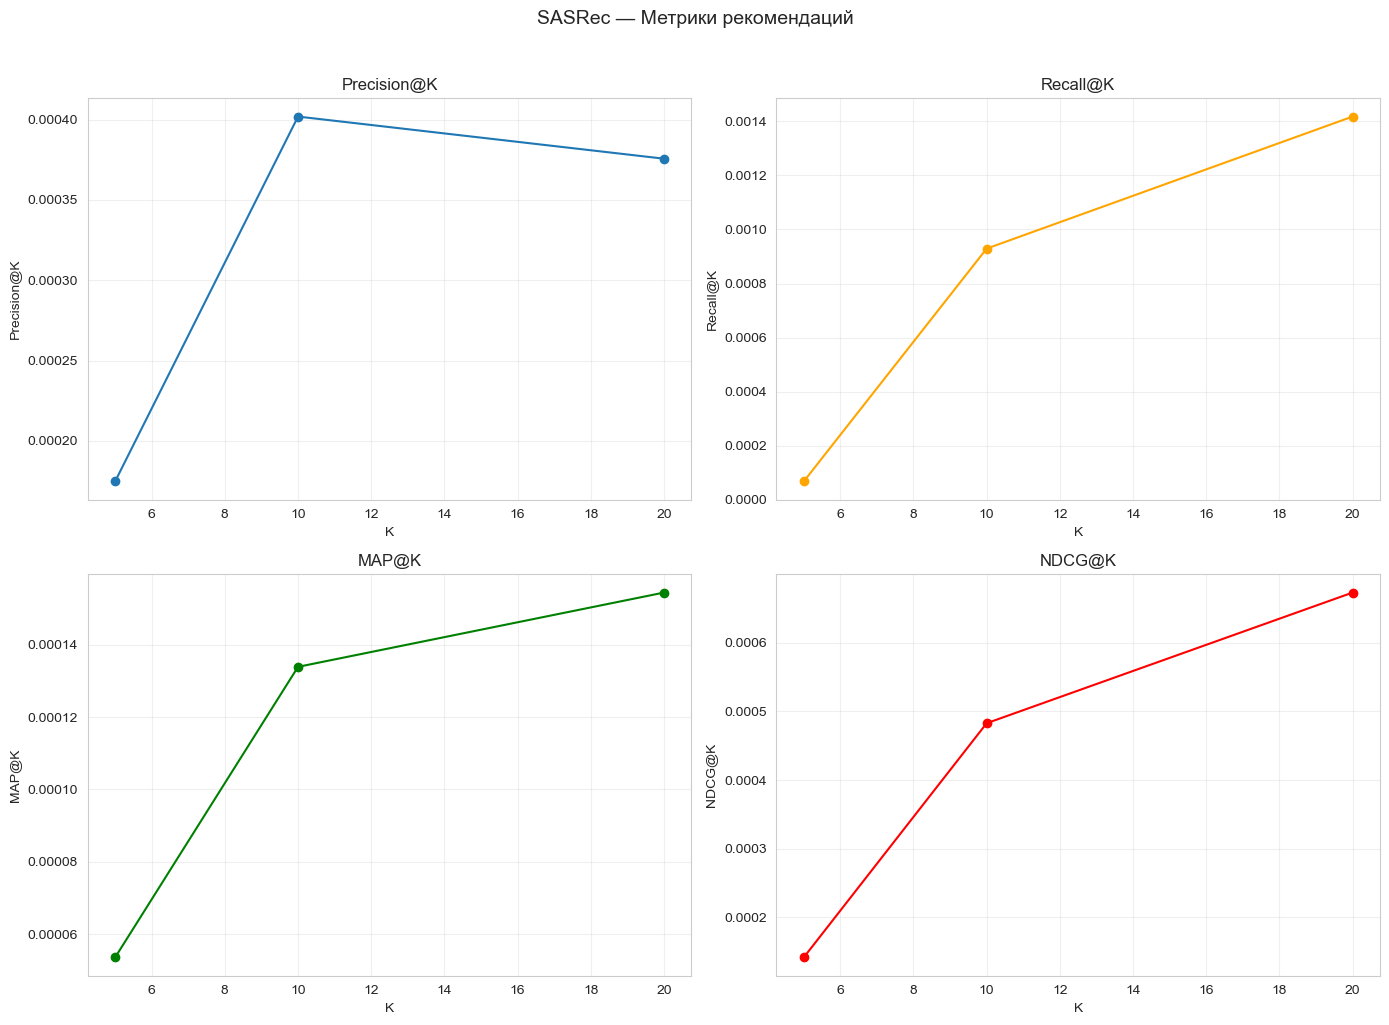

In [42]:
# Визуализация метрик
metrics_df = pd.DataFrame(results).T
metrics_df.index.name = 'K'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(metrics_df.index, metrics_df['precision'], marker='o')
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Precision@K')
axes[0, 0].set_title('Precision@K'); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(metrics_df.index, metrics_df['recall'], marker='o', color='orange')
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Recall@K')
axes[0, 1].set_title('Recall@K'); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(metrics_df.index, metrics_df['map'], marker='o', color='green')
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('MAP@K')
axes[1, 0].set_title('MAP@K'); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metrics_df.index, metrics_df['ndcg'], marker='o', color='red')
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('NDCG@K')
axes[1, 1].set_title('NDCG@K'); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('SASRec — Метрики рекомендаций', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Сравнение с ALS и NCF

In [43]:
# Результаты ALS и NCF из предыдущих экспериментов
als_results = {
    5:  {'precision': 0.0343, 'recall': 0.0385, 'map': 0.0301, 'ndcg': 0.0468},
    10: {'precision': 0.0254, 'recall': 0.0514, 'map': 0.0273, 'ndcg': 0.0479},
    20: {'precision': 0.0185, 'recall': 0.0702, 'map': 0.0275, 'ndcg': 0.0527},
}
ncf_results = {
    5:  {'precision': 0.0099, 'recall': 0.0141, 'map': 0.0092, 'ndcg': 0.0145},
    10: {'precision': 0.0091, 'recall': 0.0230, 'map': 0.0096, 'ndcg': 0.0178},
    20: {'precision': 0.0086, 'recall': 0.0398, 'map': 0.0107, 'ndcg': 0.0237},
}

comparison = []
for k in [5, 10, 20]:
    for metric in ['precision', 'recall', 'map', 'ndcg']:
        comparison.append({
            'K': k,
            'Metric': f"{metric.upper()}@{k}" if metric != 'precision' else f"Precision@{k}",
            'ALS': als_results[k][metric],
            'NCF': ncf_results[k][metric],
            'SASRec': results[k][metric],
        })

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

 K       Metric    ALS    NCF   SASRec
 5  Precision@5 0.0343 0.0099 0.000175
 5     RECALL@5 0.0385 0.0141 0.000067
 5        MAP@5 0.0301 0.0092 0.000054
 5       NDCG@5 0.0468 0.0145 0.000141
10 Precision@10 0.0254 0.0091 0.000402
10    RECALL@10 0.0514 0.0230 0.000929
10       MAP@10 0.0273 0.0096 0.000134
10      NDCG@10 0.0479 0.0178 0.000483
20 Precision@20 0.0185 0.0086 0.000376
20    RECALL@20 0.0702 0.0398 0.001418
20       MAP@20 0.0275 0.0107 0.000154
20      NDCG@20 0.0527 0.0237 0.000673


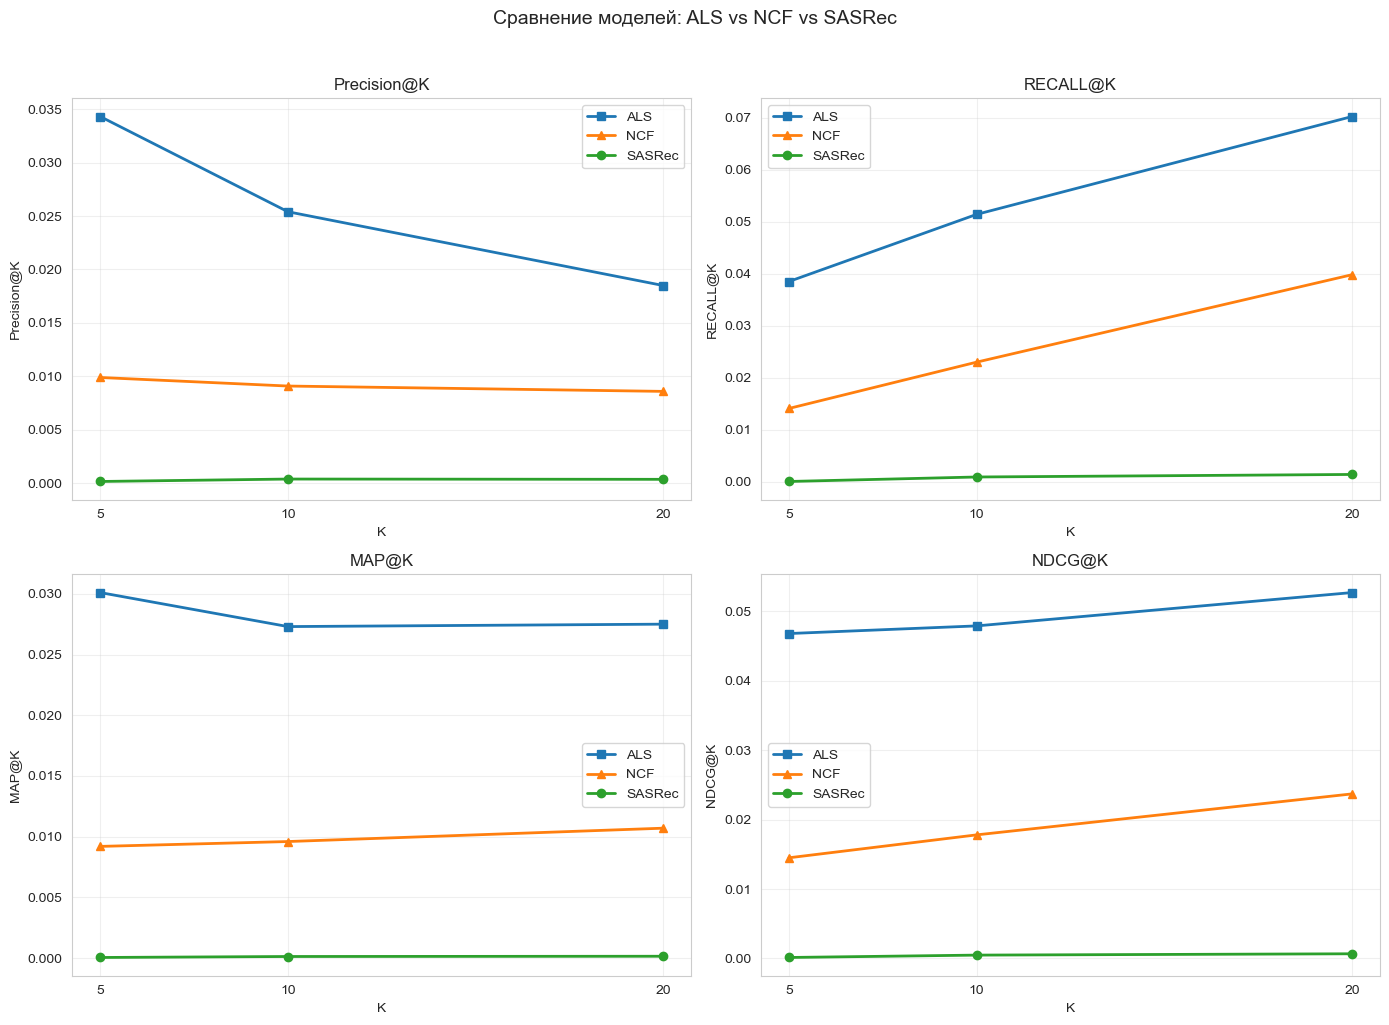

In [44]:
# Сравнительные графики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
k_vals = [5, 10, 20]

for idx, metric in enumerate(['precision', 'recall', 'map', 'ndcg']):
    ax = axes[idx // 2, idx % 2]
    
    als_vals = [als_results[k][metric] for k in k_vals]
    ncf_vals = [ncf_results[k][metric] for k in k_vals]
    sasrec_vals = [results[k][metric] for k in k_vals]
    
    ax.plot(k_vals, als_vals, marker='s', label='ALS', linewidth=2)
    ax.plot(k_vals, ncf_vals, marker='^', label='NCF', linewidth=2)
    ax.plot(k_vals, sasrec_vals, marker='o', label='SASRec', linewidth=2)
    
    title = metric.upper() if metric != 'precision' else 'Precision'
    ax.set_xlabel('K')
    ax.set_ylabel(f'{title}@K')
    ax.set_title(f'{title}@K')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(k_vals)

plt.suptitle('Сравнение моделей: ALS vs NCF vs SASRec', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()